# CNN-core TRM-style recursion on CIFAR-10

Compare a CNN baseline with TRM-style recursive variants on CIFAR-10. Pipeline: `RGB image -> CNN feature map x -> initialize prediction y and reasoning z -> shared CNN core recursion -> flatten -> classifier`.

CIFAR-10 is harder than MNIST. This notebook uses the complete CIFAR-10 dataset: 50,000 official training images and 10,000 official test images. A fixed 5,000-image subset of the official training split is reserved for validation.

In [1]:
# Imports and reproducibility
from __future__ import annotations

import random
from copy import deepcopy
from dataclasses import dataclass

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SEED = 7
random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Using device: {device}')

Using device: cuda


## Load full CIFAR-10 data

Training uses random crop and horizontal flip. Validation and test use only normalization. Both training and validation subsets reference the same official training images with different transform pipelines.

In [2]:
from pathlib import Path

BATCH_SIZE = 512
VALIDATION_SIZE = 5_000
NUM_WORKERS = 8
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

kaggle_matches = list(Path('/kaggle/input').rglob('cifar-10-batches-py'))

if kaggle_matches:
    data_root = kaggle_matches[0].parent
    should_download = False
else:
    data_root = Path('./data')
    should_download = True

print(f'data_root={data_root}')
print(f'should_download={should_download}')

train_source = datasets.CIFAR10(
    root=data_root,
    train=True,
    download=should_download,
    transform=train_transform,
)

eval_source = datasets.CIFAR10(
    root=data_root,
    train=True,
    download=False,
    transform=eval_transform,
)

test_dataset = datasets.CIFAR10(
    root=data_root,
    train=False,
    download=should_download,
    transform=eval_transform,
)

indices = torch.randperm(
    len(train_source),
    generator=torch.Generator().manual_seed(SEED),
).tolist()

val_indices = indices[:VALIDATION_SIZE]
train_indices = indices[VALIDATION_SIZE:]

train_dataset = Subset(train_source, train_indices)
val_dataset = Subset(eval_source, val_indices)

loader_options = {
    'batch_size': BATCH_SIZE,
    'num_workers': NUM_WORKERS,
    'pin_memory': device.type == 'cuda',
    'persistent_workers': NUM_WORKERS > 0,
}

train_loader = DataLoader(train_dataset, shuffle=True, **loader_options)
val_loader = DataLoader(val_dataset, **loader_options)
test_loader = DataLoader(test_dataset, **loader_options)

print(f'train={len(train_dataset):,}, val={len(val_dataset):,}, test={len(test_dataset):,}')

data_root=/kaggle/input/datasets/miphu2005/cifar10-test
should_download=False
train=45,000, val=5,000, test=10,000


## Models

All variants use the same CNN feature extractor and projection. `CNNTRMClassifier` keeps image feature `x`, prediction state `y`, and reasoning state `z` as `8x8` feature maps. A shared CNN core refines `z` in an inner loop and updates `y` in an outer loop. Training applies deep supervision to each outer-loop prediction.

In [3]:
class SwiGLU(nn.Module):
    def forward(self, x):
        gate, value = x.chunk(2, dim=1)
        return F.silu(gate) * value


class CNNEncoder(nn.Module):
    def __init__(self, hidden_dim: int = 256):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_dim),
            nn.GELU(),
        )
        self.projection = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_dim * 8 * 8, hidden_dim * 2),
            SwiGLU(),
            nn.LayerNorm(hidden_dim),
        )

    def forward(self, x):
        return self.projection(self.feature_extractor(x))


class SimpleCNNCIFAR10(nn.Module):
    def __init__(self, hidden_dim: int = 256, num_classes: int = 10):
        super().__init__()
        self.encoder = CNNEncoder(hidden_dim=hidden_dim)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        return self.classifier(self.encoder(x))


class SharedCNNTRMCore(nn.Module):
    def __init__(self, hidden_dim: int, gate_bias: float = -2.0):
        super().__init__()
        self.input_projection = nn.Sequential(
            nn.Conv2d(hidden_dim * 3, hidden_dim, kernel_size=1),
            nn.GroupNorm(32, hidden_dim),
            nn.GELU(),
        )
        self.candidate = nn.Sequential(
            nn.Conv2d(hidden_dim, hidden_dim * 2, kernel_size=3, padding=1),
            SwiGLU(),
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
        )
        self.gate = nn.Conv2d(hidden_dim * 2, hidden_dim, kernel_size=1)
        nn.init.constant_(self.gate.bias, gate_bias)

    def forward(self, x, y, state):
        candidate = self.candidate(self.input_projection(torch.cat([x, y, state], dim=1)))
        gate = torch.sigmoid(self.gate(torch.cat([state, candidate], dim=1)))
        return gate * candidate + (1.0 - gate) * state


class CNNTRMClassifier(nn.Module):
    def __init__(self, hidden_dim: int = 256, num_classes: int = 10, inner_steps: int = 2, outer_steps: int = 4):
        super().__init__()
        self.inner_steps = inner_steps
        self.outer_steps = outer_steps
        self.encoder = CNNEncoder(hidden_dim=hidden_dim)
        self.core = SharedCNNTRMCore(hidden_dim=hidden_dim)
        self.prediction_init = nn.Parameter(torch.zeros(1, hidden_dim, 8, 8))
        self.reasoning_init = nn.Parameter(torch.zeros(1, hidden_dim, 8, 8))
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.encoder.feature_extractor(x)
        batch_size = x.size(0)
        y = self.prediction_init.expand(batch_size, -1, -1, -1)
        z = self.reasoning_init.expand(batch_size, -1, -1, -1)
        logits_by_step = []
        for _ in range(self.outer_steps):
            for _ in range(self.inner_steps):
                z = self.core(x, y, z)
            y = self.core(x, y, z)
            logits_by_step.append(self.classifier(self.encoder.projection(y)))
        return logits_by_step

## Training helpers

The default run allows up to 50 epochs with cosine learning-rate decay and early stopping. Each experiment records train and validation accuracy/loss once per epoch, then restores the weights with the best validation loss.

In [4]:
@dataclass
class Metrics:
    loss: float
    accuracy: float


def run_epoch(model, loader, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.set_grad_enabled(is_training):
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            model_output = model(images)
            logits_by_step = model_output if isinstance(model_output, list) else [model_output]
            logits = logits_by_step[-1]
            loss = torch.stack([F.cross_entropy(step_logits, labels) for step_logits in logits_by_step]).mean()
            if is_training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * labels.size(0)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += labels.size(0)

    return Metrics(loss=total_loss / total_samples, accuracy=total_correct / total_samples)


def train_model(model, epochs=50, lr=1e-3, weight_decay=1e-4, patience=7, min_delta=1e-4):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}
    best_val_loss = float('inf')
    best_state = None
    stale_epochs = 0

    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(model, train_loader, optimizer)
        val_metrics = run_epoch(model, val_loader)
        history['loss'].append(train_metrics.loss)
        history['val_loss'].append(val_metrics.loss)
        history['accuracy'].append(train_metrics.accuracy)
        history['val_accuracy'].append(val_metrics.accuracy)
        print(f'epoch={epoch:02d} loss={train_metrics.loss:.4f} val_loss={val_metrics.loss:.4f} acc={train_metrics.accuracy:.4f} val_acc={val_metrics.accuracy:.4f}')
        scheduler.step()
        if val_metrics.loss < best_val_loss - min_delta:
            best_val_loss = val_metrics.loss
            best_state = deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= patience:
                print(f'early stopping at epoch={epoch:02d}; best_val_loss={best_val_loss:.4f}')
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history

## Run full comparison

`50` is the maximum epoch count. Early stopping halts a model after `PATIENCE` epochs without meaningful validation-loss improvement. Reduce `EPOCHS` to `1` only for a smoke test.

In [5]:
EPOCHS = 50
PATIENCE = 7
HIDDEN_DIM = 256
INNER_STEPS = 2

experiments = {
    'CNN baseline': lambda: SimpleCNNCIFAR10(hidden_dim=HIDDEN_DIM),
    'CNN + TRM outer=1': lambda: CNNTRMClassifier(hidden_dim=HIDDEN_DIM, inner_steps=INNER_STEPS, outer_steps=1),
    'CNN + TRM outer=2': lambda: CNNTRMClassifier(hidden_dim=HIDDEN_DIM, inner_steps=INNER_STEPS, outer_steps=2),
    'CNN + TRM outer=4': lambda: CNNTRMClassifier(hidden_dim=HIDDEN_DIM, inner_steps=INNER_STEPS, outer_steps=4),
}

trained_models = {}
histories = {}
for name, build_model in experiments.items():
    print(f'\n=== {name} ===')
    trained_models[name], histories[name] = train_model(build_model(), epochs=EPOCHS, patience=PATIENCE)


=== CNN baseline ===
epoch=01 loss=1.5039 val_loss=1.2370 acc=0.4510 val_acc=0.5474
epoch=02 loss=1.0768 val_loss=0.9909 acc=0.6169 val_acc=0.6440
epoch=03 loss=0.9003 val_loss=0.7913 acc=0.6823 val_acc=0.7182
epoch=04 loss=0.7902 val_loss=0.7387 acc=0.7221 val_acc=0.7382
epoch=05 loss=0.7218 val_loss=0.6854 acc=0.7474 val_acc=0.7612
epoch=06 loss=0.6641 val_loss=0.6199 acc=0.7693 val_acc=0.7810
epoch=07 loss=0.6091 val_loss=0.6921 acc=0.7889 val_acc=0.7588
epoch=08 loss=0.5692 val_loss=0.6856 acc=0.8005 val_acc=0.7584
epoch=09 loss=0.5383 val_loss=0.6299 acc=0.8110 val_acc=0.7854
epoch=10 loss=0.5140 val_loss=0.5395 acc=0.8207 val_acc=0.8062
epoch=11 loss=0.4824 val_loss=0.5686 acc=0.8327 val_acc=0.7932
epoch=12 loss=0.4491 val_loss=0.5942 acc=0.8430 val_acc=0.8022
epoch=13 loss=0.4273 val_loss=0.6146 acc=0.8500 val_acc=0.7904
epoch=14 loss=0.4051 val_loss=0.5209 acc=0.8591 val_acc=0.8226
epoch=15 loss=0.3855 val_loss=0.5805 acc=0.8649 val_acc=0.8106
epoch=16 loss=0.3649 val_loss=0.5

## Plot train and validation metrics

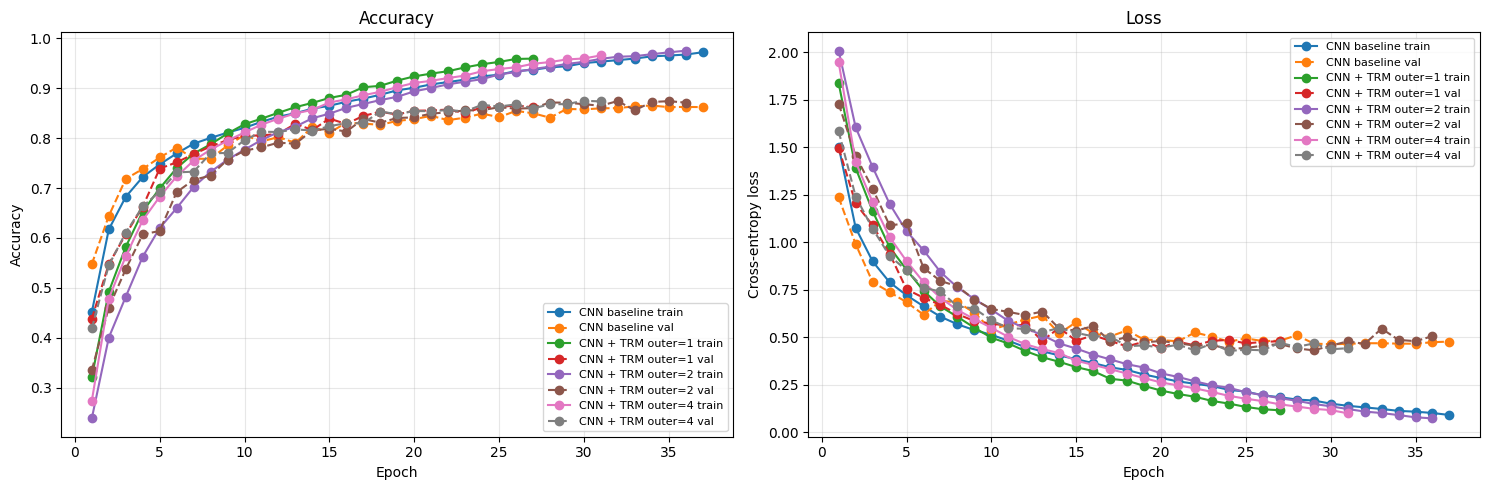

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for name, history in histories.items():
    epochs = range(1, len(history['loss']) + 1)
    axes[0].plot(epochs, history['accuracy'], marker='o', label=f'{name} train')
    axes[0].plot(epochs, history['val_accuracy'], marker='o', linestyle='--', label=f'{name} val')
    axes[1].plot(epochs, history['loss'], marker='o', label=f'{name} train')
    axes[1].plot(epochs, history['val_loss'], marker='o', linestyle='--', label=f'{name} val')
axes[0].set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
axes[1].set(title='Loss', xlabel='Epoch', ylabel='Cross-entropy loss')
for axis in axes:
    axis.grid(alpha=0.3)
    axis.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Test comparison

Use test accuracy only after reviewing validation metrics.

In [7]:
summary = []
for name, model in trained_models.items():
    test_metrics = run_epoch(model, test_loader)
    summary.append({
        'model': name,
        'parameters': sum(parameter.numel() for parameter in model.parameters()),
        'final_val_accuracy': histories[name]['val_accuracy'][-1],
        'test_accuracy': test_metrics.accuracy,
        'test_loss': test_metrics.loss,
    })
for result in sorted(summary, key=lambda item: item['test_accuracy'], reverse=True):
    print(result)

{'model': 'CNN + TRM outer=2', 'parameters': 10895626, 'final_val_accuracy': 0.8712, 'test_accuracy': 0.8676, 'test_loss': 0.44026126136779786}
{'model': 'CNN + TRM outer=4', 'parameters': 10895626, 'final_val_accuracy': 0.8736, 'test_accuracy': 0.8659, 'test_loss': 0.43320824875831604}
{'model': 'CNN baseline', 'parameters': 8763914, 'final_val_accuracy': 0.8622, 'test_accuracy': 0.8581, 'test_loss': 0.48305029368400576}
{'model': 'CNN + TRM outer=1', 'parameters': 10895626, 'final_val_accuracy': 0.8618, 'test_accuracy': 0.8568, 'test_loss': 0.46137993021011353}


## Interpretation checklist

- Compare `CNN + TRM outer=1/2/4` while keeping `INNER_STEPS=2` fixed.
- Each outer step refines reasoning map `z` several times, updates prediction map `y`, and emits supervised logits.
- Compare recursive variants with `CNN baseline`; all models share the same image encoder architecture.
- Check validation loss for overfitting before selecting a model.
- The CNN encoder preserves local pixel relationships before recurrent latent refinement.

## Clear VRAM cache


In [8]:
import gc
import torch

trained_models.clear()
histories.clear()

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    print('CUDA VRAM cache cleared')
elif torch.backends.mps.is_available():
    torch.mps.empty_cache()
    print('MPS cache cleared')
else:
    print('CPU mode: no VRAM cache to clear')

CUDA VRAM cache cleared
